# 04 — Expanded selected-dataset diagnostic suite
Run All: five-class Kinetics-600 (>2,000 unique videos before splitting) → temporal audit → tiny training-only learning check → model screen and one-factor comparisons → two-seed confirmation → freeze → test metrics and videos. An eight-hour cooperative compute deadline starts after data setup; incomplete studies cannot open test.

Saved outputs below are historical, not results of this plan. This exploratory diagnostic is separate from the unchanged controlled AAD protocol and original reference notebook. Do not tune from test results.

In [3]:
from pathlib import Path
import subprocess
import sys
import importlib
import os
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')

REPO_ROOT = Path('/content/phd_research')
REPO_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not (REPO_ROOT / '.git').exists():
    if REPO_ROOT.exists() and any(REPO_ROOT.iterdir()):
        raise RuntimeError(f'{REPO_ROOT} contains files but is not a Git checkout. Use an empty checkout path; existing files were preserved.')
    subprocess.run(['git', 'clone', 'https://github.com/sanelehlabisa/phd_research.git', str(REPO_ROOT)], check=True)
else:
    update = subprocess.run(['git', 'pull', '--ff-only', 'origin', 'master'], cwd=REPO_ROOT, capture_output=True, text=True)
    print(update.stdout, flush=True)
    if update.returncode:
        raise RuntimeError('Cannot safely update the Colab checkout. Save/commit conflicting local edits, resolve the Git error, then rerun setup. No local edits were discarded.\n' + update.stderr)
IMPLEMENTATION_ROOT = REPO_ROOT / 'papers/001-journal-abnormal-activity-recognition/implementation'
required_helpers = ('notebook_data.py', 'notebook_display.py', 'notebook_workflows.py', 'kinetics600_subset.py', 'notebook_models.py', 'notebook_suite.py', 'notebook_diagnostics.py')
missing_helpers = [name for name in required_helpers if not (IMPLEMENTATION_ROOT / 'src' / name).is_file()]
revision = subprocess.run(['git', 'rev-parse', '--short', 'HEAD'], cwd=REPO_ROOT, capture_output=True, text=True, check=True).stdout.strip()
print(f'Code checkout: {REPO_ROOT} @ {revision}', flush=True)
print(f'Notebook Python: {sys.executable}', flush=True)
try:
    gpu = subprocess.run(['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'], capture_output=True, text=True, timeout=15)
    print('Attached GPU:', gpu.stdout.strip() or gpu.stderr.strip(), flush=True)
except (OSError, subprocess.TimeoutExpired) as error:
    print('GPU check:', error, flush=True)
if missing_helpers:
    raise RuntimeError(f'Colab checkout is missing repository files: {missing_helpers}. These are NOT pip packages. Commit and push the complete notebook/source update to master, then rerun this setup cell. A kernel restart alone cannot download unpublished files.')
bootstrap = subprocess.run([sys.executable, str(IMPLEMENTATION_ROOT / 'src/colab_bootstrap.py'), str(IMPLEMENTATION_ROOT / 'requirements.txt')])
if bootstrap.returncode == 75:
    raise SystemExit('Restart the Colab runtime, reconnect to the A100, and rerun from the top.')
bootstrap.check_returncode()
sys.path[:] = [str(IMPLEMENTATION_ROOT)] + [entry for entry in sys.path if entry != str(IMPLEMENTATION_ROOT)]
for name in [name for name in sys.modules if name == 'src' or name.startswith('src.')]:
    del sys.modules[name]
importlib.invalidate_caches()
from src.notebook_utils import validate_runtime
print(validate_runtime(require_cuda=True))
from src.notebook_suite import prepare_experiment_data
prepared = prepare_experiment_data(IMPLEMENTATION_ROOT)


Already up to date.

Code checkout: /content/phd_research @ a9ff7f8
Notebook Python: /usr/bin/python3
Attached GPU: NVIDIA A100-SXM4-80GB


RuntimeError: Colab checkout is missing repository files: ['kinetics600_subset.py']. These are NOT pip packages. Commit and push the complete notebook/source update to master, then rerun this setup cell. A kernel restart alone cannot download unpublished files.

## Declared candidates, factors and budgets
Screen 11 custom models and three scratch 3D CNNs for 24 epochs at 64×64, 32 frames/8 FPS. Against the validation-selected custom reference, change one factor at a time: 64/96/128 pixels, 4/8/16 FPS coverage, dropout 0/0.1/0.5 and weight decay 0/0.0001/0.001. Try the native published topology separately without shrinking it. The displayed plan includes run counts; the eight-hour cap may stop before all runs finish. Configure this suite with SUITE_* settings, not the retained legacy quick-grid SCREEN_* lists.

In [ ]:
from src.notebook_suite import show_experiment_plan, run_screen, train_winner, final_evaluate
screen_dir = final_data = None  # Clear any previous run before starting.
plan = show_experiment_plan(prepared)


,candidate,layers,epochs,resolution,frames,batch,learning_rate,seed
0,width_8,"[[8, [3, 3]]]",8,32x32,16,8,0.001,42
1,depth_8_16,"[[8, [3, 3]], [16, [3, 3]]]",8,32x32,16,8,0.001,42
2,depth_8_8_8,"[[8, [3, 3]], [8, [3, 3]], [8, [3, 3]]]",8,32x32,16,8,0.001,42


Then retrain the validation winner from scratch: 24 epochs, 64x64; freeze before final test.
Exploratory single-seed diagnostic, not the controlled AAD paper screen.


Candidate 1/3: width_8
Training width_8 on cuda: 8 epochs, 32x32, ((8, (3, 3)),)
Artifacts: /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261005_135351_818328_kinetics-400-dataset_width_8
Epoch 1/8
  width_8: 8/60 clips | batch loss=1.7658


/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  width_8: 60/60 clips | batch loss=1.6767
  Validating complete validation partition...
  width_8: 13/13 clips | batch loss=1.4348
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261005_135351_818328_kinetics-400-dataset_width_8/checkpoints/best_model.pth
  train loss=1.6590, acc=15.0% | val loss=1.6505, acc=15.4%


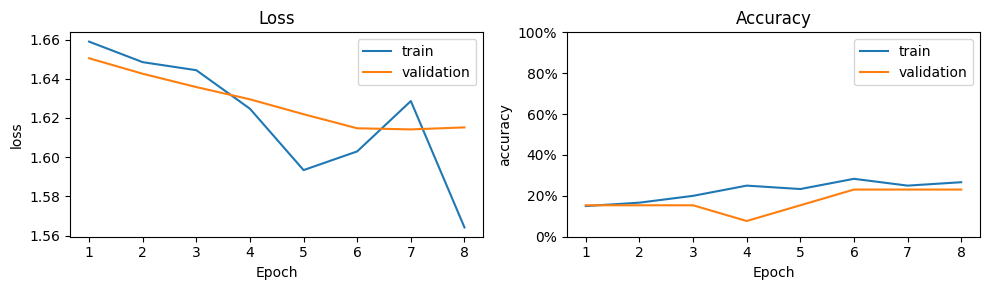

Epoch 2/8
  width_8: 60/60 clips | batch loss=1.7079
  Validating complete validation partition...
  width_8: 13/13 clips | batch loss=1.4468
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261005_135351_818328_kinetics-400-dataset_width_8/checkpoints/best_model.pth
  train loss=1.6485, acc=16.7% | val loss=1.6426, acc=15.4%
Epoch 3/8
  width_8: 60/60 clips | batch loss=1.7650
  Validating complete validation partition...
  width_8: 13/13 clips | batch loss=1.4640
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261005_135351_818328_kinetics-400-dataset_width_8/checkpoints/best_model.pth
  train loss=1.6444, acc=20.0% | val loss=1.6358, acc=15.4%
Epoch 4/8
  width_8: 60/60 clips | batch loss=1.5912
  Validating complete validation partition...
  width_8: 13/13 clips | batch loss=1.4802
✅ Saved checkpoint to /content/phd_research/papers/001-jou

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  depth_8_16: 13/13 clips | batch loss=1.6897
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261005_135400_010341_kinetics-400-dataset_depth_8_16/checkpoints/best_model.pth
  train loss=1.6196, acc=18.3% | val loss=1.6087, acc=23.1%


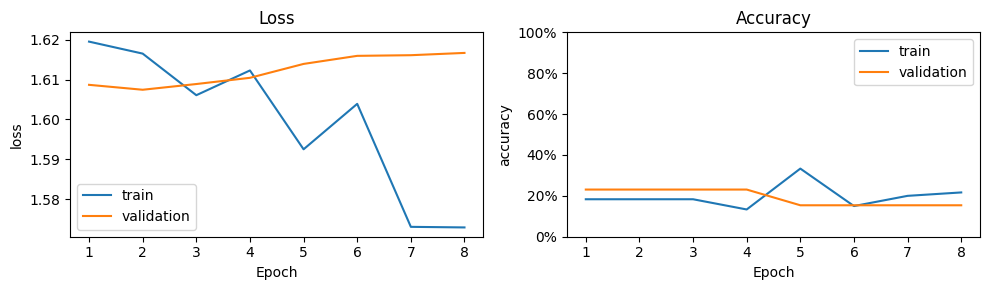

Epoch 2/8
  depth_8_16: 60/60 clips | batch loss=1.6190
  Validating complete validation partition...
  depth_8_16: 13/13 clips | batch loss=1.6868
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261005_135400_010341_kinetics-400-dataset_depth_8_16/checkpoints/best_model.pth
  train loss=1.6166, acc=18.3% | val loss=1.6075, acc=23.1%
Epoch 3/8
  depth_8_16: 60/60 clips | batch loss=1.6578
  Validating complete validation partition...
  depth_8_16: 13/13 clips | batch loss=1.6963
  train loss=1.6061, acc=18.3% | val loss=1.6089, acc=23.1%
Epoch 4/8
  depth_8_16: 60/60 clips | batch loss=1.5241
  Validating complete validation partition...
  depth_8_16: 13/13 clips | batch loss=1.7264
  train loss=1.6123, acc=13.3% | val loss=1.6105, acc=23.1%
Epoch 5/8
  depth_8_16: 60/60 clips | batch loss=1.3981
  Validating complete validation partition...
  depth_8_16: 13/13 clips | batch loss=1.7265
  train loss=1.5925, acc=33

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  depth_8_8_8: 60/60 clips | batch loss=1.7174
  Validating complete validation partition...
  depth_8_8_8: 13/13 clips | batch loss=1.9006
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261005_135405_409939_kinetics-400-dataset_depth_8_8_8/checkpoints/best_model.pth
  train loss=1.6508, acc=16.7% | val loss=1.6653, acc=15.4%


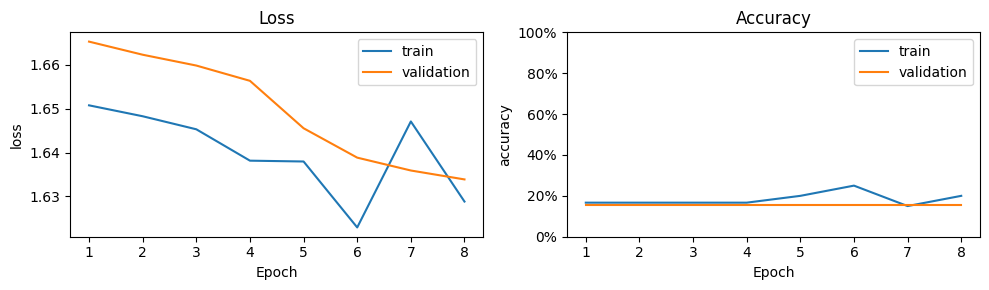

Epoch 2/8
  depth_8_8_8: 60/60 clips | batch loss=1.4586
  Validating complete validation partition...
  depth_8_8_8: 13/13 clips | batch loss=1.8893
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261005_135405_409939_kinetics-400-dataset_depth_8_8_8/checkpoints/best_model.pth
  train loss=1.6483, acc=16.7% | val loss=1.6623, acc=15.4%
Epoch 3/8
  depth_8_8_8: 60/60 clips | batch loss=1.4677
  Validating complete validation partition...
  depth_8_8_8: 13/13 clips | batch loss=1.8795
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261005_135405_409939_kinetics-400-dataset_depth_8_8_8/checkpoints/best_model.pth
  train loss=1.6453, acc=16.7% | val loss=1.6599, acc=15.4%
Epoch 4/8
  depth_8_8_8: 60/60 clips | batch loss=1.7435
  Validating complete validation partition...
  depth_8_8_8: 13/13 clips | batch loss=1.8617
✅ Saved checkpoint to /con

,candidate,loss,accuracy,macro_precision,macro_recall,macro_f1,parameters
0,width_8,1.614174,0.230769,0.050000,0.2,0.080000,3245
1,depth_8_16,1.607474,0.230769,0.046154,0.2,0.075000,17173
2,depth_8_8_8,1.633858,0.153846,0.030769,0.2,0.053333,12525


In [ ]:
screen_dir = run_screen(prepared)


## Longer confirmation and validation-only freeze
Train the selected custom configuration and all three CNNs from scratch for 64 epochs, seeds 42/2026, at max(96, selected spatial size). Use identical splits, sampling and budgets; report mean/std validation metrics. Freeze every compatible checkpoint before opening test. No test evaluation after an incomplete suite.

Dataset: kinetics-subset | sanelehlabisa/kinetics-400-dataset/versions/1
Matched Kinetics classes: ['headbutting', 'hugging', 'punching_person__boxing_', 'shaking_hands', 'slapping']
Skipped absent interests: ['Begging', 'Drunkenness', 'Fight', 'Harassment', 'Hijack', 'Knife Hazard', 'Normal Videos', 'Pollution', 'Property Damage', 'Robbery', 'Terrorism', 'non-violent', 'violent']
Accepted classes: ['headbutting', 'hugging', 'punching_person__boxing_', 'shaking_hands', 'slapping']
Locating class folders and building file inventory (no video decoding)...
✅ 87 videos | mode=video | 5 classes: ['headbutting', 'hugging', 'punching_person__boxing_', 'shaking_hands', 'slapping']
train class counts: {'headbutting': 15, 'hugging': 11, 'punching_person__boxing_': 10, 'shaking_hands': 15, 'slapping': 9}
train majority-class baseline: 25.0%
validation class counts: {'headbutting': 3, 'hugging': 3, 'punching_person__boxing_': 2, 'shaking_hands': 3, 'slapping': 2}
validation majority-class baseline

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  width_8-longer: 60/60 clips | batch loss=1.6769
  Validating complete validation partition...
  width_8-longer: 13/13 clips | batch loss=1.4345
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261005_135230_935813_kinetics-400-dataset_width_8-longer/checkpoints/best_model.pth
  train loss=1.6591, acc=15.0% | val loss=1.6505, acc=15.4%


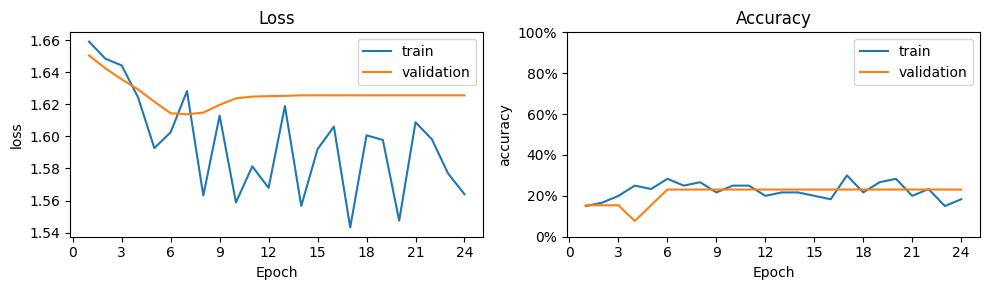

Epoch 2/24
  width_8-longer: 60/60 clips | batch loss=1.7077
  Validating complete validation partition...
  width_8-longer: 13/13 clips | batch loss=1.4469
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261005_135230_935813_kinetics-400-dataset_width_8-longer/checkpoints/best_model.pth
  train loss=1.6485, acc=16.7% | val loss=1.6425, acc=15.4%
Epoch 3/24
  width_8-longer: 60/60 clips | batch loss=1.7650
  Validating complete validation partition...
  width_8-longer: 13/13 clips | batch loss=1.4644
✅ Saved checkpoint to /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261005_135230_935813_kinetics-400-dataset_width_8-longer/checkpoints/best_model.pth
  train loss=1.6443, acc=20.0% | val loss=1.6356, acc=15.4%
Epoch 4/24
  width_8-longer: 60/60 clips | batch loss=1.5905
  Validating complete validation partition...
  width_8-longer: 13/13 clips | batch loss=1.4808

In [ ]:
final_data = train_winner(prepared, screen_dir)


## Final test metrics, then playable test predictions
Evaluate frozen confirmations without reranking from test. Show up to five test videos/probabilities from the validation winner's predeclared seed 42. Metrics and reports are saved before display; rerunning this cell reuses saved results. These diagnostics are not independent surveillance-paper evidence.

In [ ]:
final_report = final_evaluate(final_data, screen_dir)


NameError: name 'final_evaluate' is not defined